In [1]:
# Cell 1 — Imports & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv('../.env')
engine = create_engine('postgresql://ce49x@localhost:5432/conflict_monitoring')

# Veritabanından oku
df_firms = pd.read_sql("SELECT * FROM firms_detections", engine)
df_firms['acq_date'] = pd.to_datetime(df_firms['acq_date'])

print(f"FIRMS kayıt sayısı: {len(df_firms)}")
print(f"Bölgeler: {df_firms['region'].unique()}")
print(f"Tarih aralığı: {df_firms['acq_date'].min()} → {df_firms['acq_date'].max()}")

FIRMS kayıt sayısı: 533260
Bölgeler: <StringArray>
['Ukraine', 'Yemen', 'Iraq', 'Sudan', 'Syria']
Length: 5, dtype: str
Tarih aralığı: 2024-08-01 00:00:00 → 2025-02-01 00:00:00


In [2]:
# Cell 2 — Thermal Event Clustering (Simple Approach)
# Bölge + tarih bazlı gruplama, sonra 3 günlük pencere birleştirme

df_firms['acq_date'] = pd.to_datetime(df_firms['acq_date'])

# Her bölge için günlük detection sayısı → event clustering
# Basit yaklaşım: aynı bölge, 5km yakınlık, 3 gün içindeki detections = 1 event

# Adım 1: Tarih ve bölgeye göre grupla
df_firms['date_group'] = df_firms['acq_date'].dt.to_period('D')

thermal_events = df_firms.groupby(['region', 'date_group']).agg(
    centroid_lat=('latitude', 'mean'),
    centroid_lon=('longitude', 'mean'),
    total_frp=('frp', 'sum'),
    max_brightness=('bright_ti4', 'max'),
    detection_count=('frp', 'count'),
    day_detections=('daynight', lambda x: (x == 'D').sum()),
    night_detections=('daynight', lambda x: (x == 'N').sum()),
).reset_index()

thermal_events['date'] = thermal_events['date_group'].dt.to_timestamp()
thermal_events['day_night_ratio'] = (
    thermal_events['day_detections'] / 
    (thermal_events['detection_count'] + 1e-9)
)

print(f"Toplam thermal event: {len(thermal_events)}")
print(f"\nBölge bazlı event sayısı:")
print(thermal_events['region'].value_counts())
display(thermal_events.head())

Toplam thermal event: 886

Bölge bazlı event sayısı:
region
Iraq       181
Ukraine    180
Yemen      178
Syria      177
Sudan      170
Name: count, dtype: int64


,region,date_group,centroid_lat,centroid_lon,total_frp,max_brightness,detection_count,day_detections,night_detections,date,day_night_ratio
0,Iraq,2024-08-01,32.907455,46.257950,7140.84,367.0,731,303,428,2024-08-01,0.414501
1,Iraq,2024-08-02,33.072830,46.003302,3091.29,367.0,515,71,444,2024-08-02,0.137864
2,Iraq,2024-08-03,33.763164,45.437962,3019.88,367.0,520,32,488,2024-08-03,0.061538
3,Iraq,2024-08-04,33.655473,45.555199,5303.57,367.0,760,61,699,2024-08-04,0.080263
4,Iraq,2024-08-05,32.914445,46.044747,6811.45,367.0,893,218,675,2024-08-05,0.244121


In [3]:
# Cell 3 (düzeltildi) — Thermal Events'i PostgreSQL'e Yaz
te_to_save = thermal_events.copy()
te_to_save['date_group'] = te_to_save['date_group'].astype(str)

te_to_save.to_sql('thermal_events', engine, if_exists='replace', index=False)
print(f"✓ {len(te_to_save)} thermal event veritabanına yazıldı!")

✓ 886 thermal event veritabanına yazıldı!


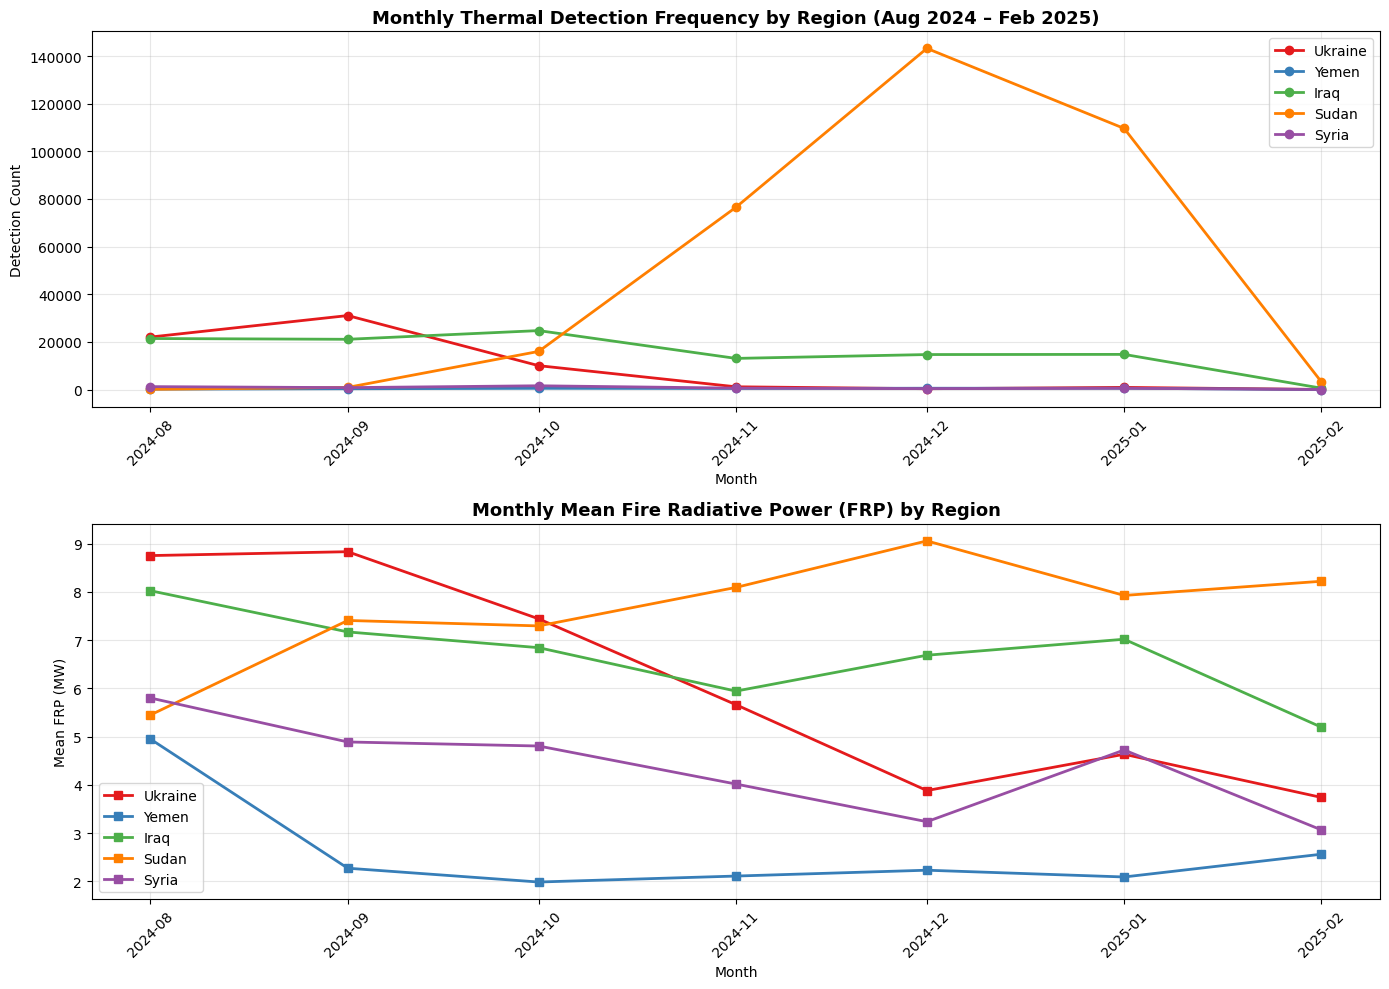

✓ Grafik kaydedildi


In [4]:
# Cell 5 — Temporal Analiz: Aylık Zaman Serisi
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

df_firms['month'] = df_firms['acq_date'].dt.to_period('M')
monthly = df_firms.groupby(['month', 'region']).size().reset_index(name='count')
monthly['month_ts'] = monthly['month'].dt.to_timestamp()

regions = ['Ukraine', 'Yemen', 'Iraq', 'Sudan', 'Syria']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

ax1 = axes[0]
for region, color in zip(regions, colors):
    data = monthly[monthly['region'] == region]
    ax1.plot(data['month_ts'], data['count'], marker='o', label=region, color=color, linewidth=2)

ax1.set_title('Monthly Thermal Detection Frequency by Region (Aug 2024 – Feb 2025)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Detection Count')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

monthly_frp = df_firms.groupby(['month', 'region'])['frp'].mean().reset_index()
monthly_frp['month_ts'] = monthly_frp['month'].dt.to_timestamp()

ax2 = axes[1]
for region, color in zip(regions, colors):
    data = monthly_frp[monthly_frp['region'] == region]
    ax2.plot(data['month_ts'], data['frp'], marker='s', label=region, color=color, linewidth=2)

ax2.set_title('Monthly Mean Fire Radiative Power (FRP) by Region', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean FRP (MW)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafik kaydedildi")

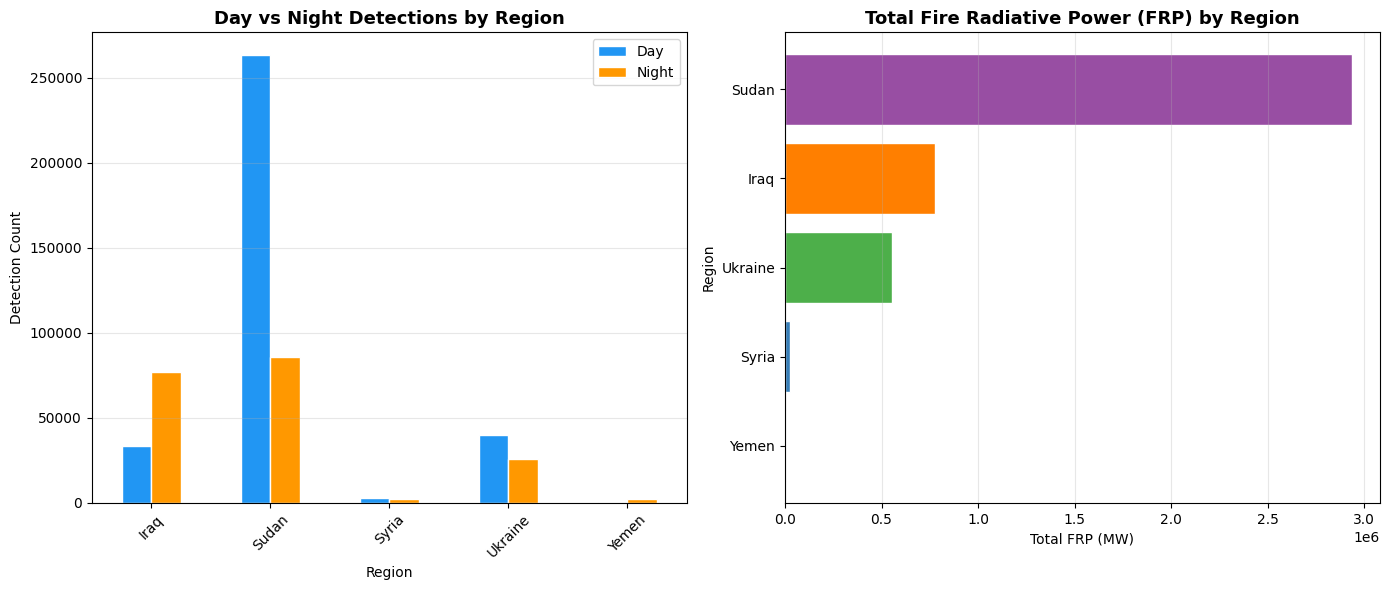

✓ Grafik kaydedildi


In [5]:
# Cell 6 — Gece/Gündüz Analizi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Gece/Gündüz detection oranı (bölge bazlı)
daynight = df_firms.groupby(['region', 'daynight']).size().reset_index(name='count')
daynight_pivot = daynight.pivot(index='region', columns='daynight', values='count').fillna(0)

daynight_pivot.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF9800'], edgecolor='white')
axes[0].set_title('Day vs Night Detections by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Detection Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Day', 'Night'])
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Bölge başına toplam FRP karşılaştırması
frp_region = df_firms.groupby('region')['frp'].agg(['sum', 'mean']).reset_index()
frp_region = frp_region.sort_values('sum', ascending=True)

axes[1].barh(frp_region['region'], frp_region['sum'], color=colors, edgecolor='white')
axes[1].set_title('Total Fire Radiative Power (FRP) by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total FRP (MW)')
axes[1].set_ylabel('Region')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../daynight_frp.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafik kaydedildi")

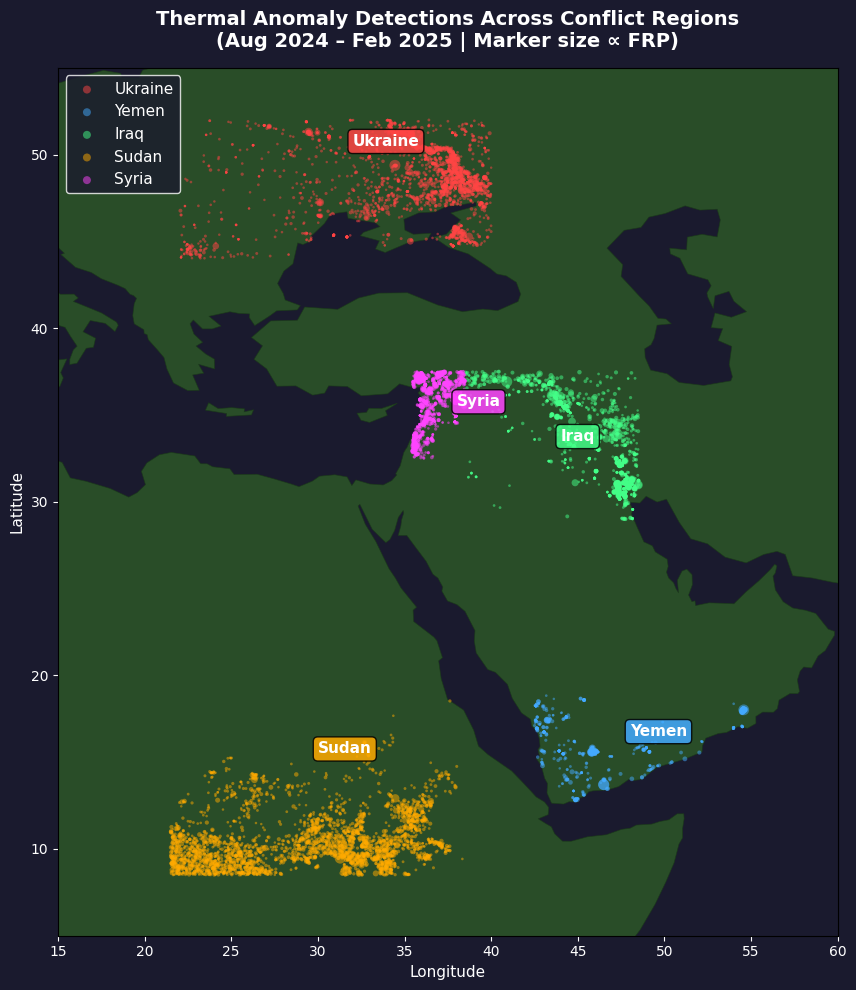

✓ Harita kaydedildi


In [6]:
# Cell 7 (düzeltildi v2) — Güzel Spatial Harita
import geopandas as gpd
import geodatasets

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

fig, ax = plt.subplots(1, 1, figsize=(16, 10))

world.plot(ax=ax, color='#2d5a27', edgecolor='#1a3a18', linewidth=0.5, alpha=0.8)
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

region_colors = {
    'Ukraine': '#ff4444',
    'Yemen': '#44aaff',
    'Iraq': '#44ff88',
    'Sudan': '#ffaa00',
    'Syria': '#ff44ff'
}

for region, color in region_colors.items():
    data = df_firms[df_firms['region'] == region].sample(
        min(3000, len(df_firms[df_firms['region'] == region])), random_state=42)
    sizes = (data['frp'] / data['frp'].max() * 60 + 3)
    ax.scatter(data['longitude'], data['latitude'],
               c=color, s=sizes, alpha=0.5, label=region, edgecolors='none', zorder=3)

centers = {
    'Ukraine': (32, 50.5), 'Yemen': (48, 16.5),
    'Iraq': (44, 33.5), 'Sudan': (30, 15.5), 'Syria': (38, 35.5)
}
for region, (lon, lat) in centers.items():
    ax.annotate(region, (lon, lat), fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=region_colors[region], alpha=0.85))

ax.set_xlim(15, 60)
ax.set_ylim(5, 55)
ax.set_xlabel('Longitude', fontsize=11, color='white')
ax.set_ylabel('Latitude', fontsize=11, color='white')
ax.set_title('Thermal Anomaly Detections Across Conflict Regions\n(Aug 2024 – Feb 2025 | Marker size ∝ FRP)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(colors='white')
ax.legend(loc='upper left', fontsize=11, facecolor='#1a1a2e', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.savefig('../spatial_map.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✓ Harita kaydedildi")

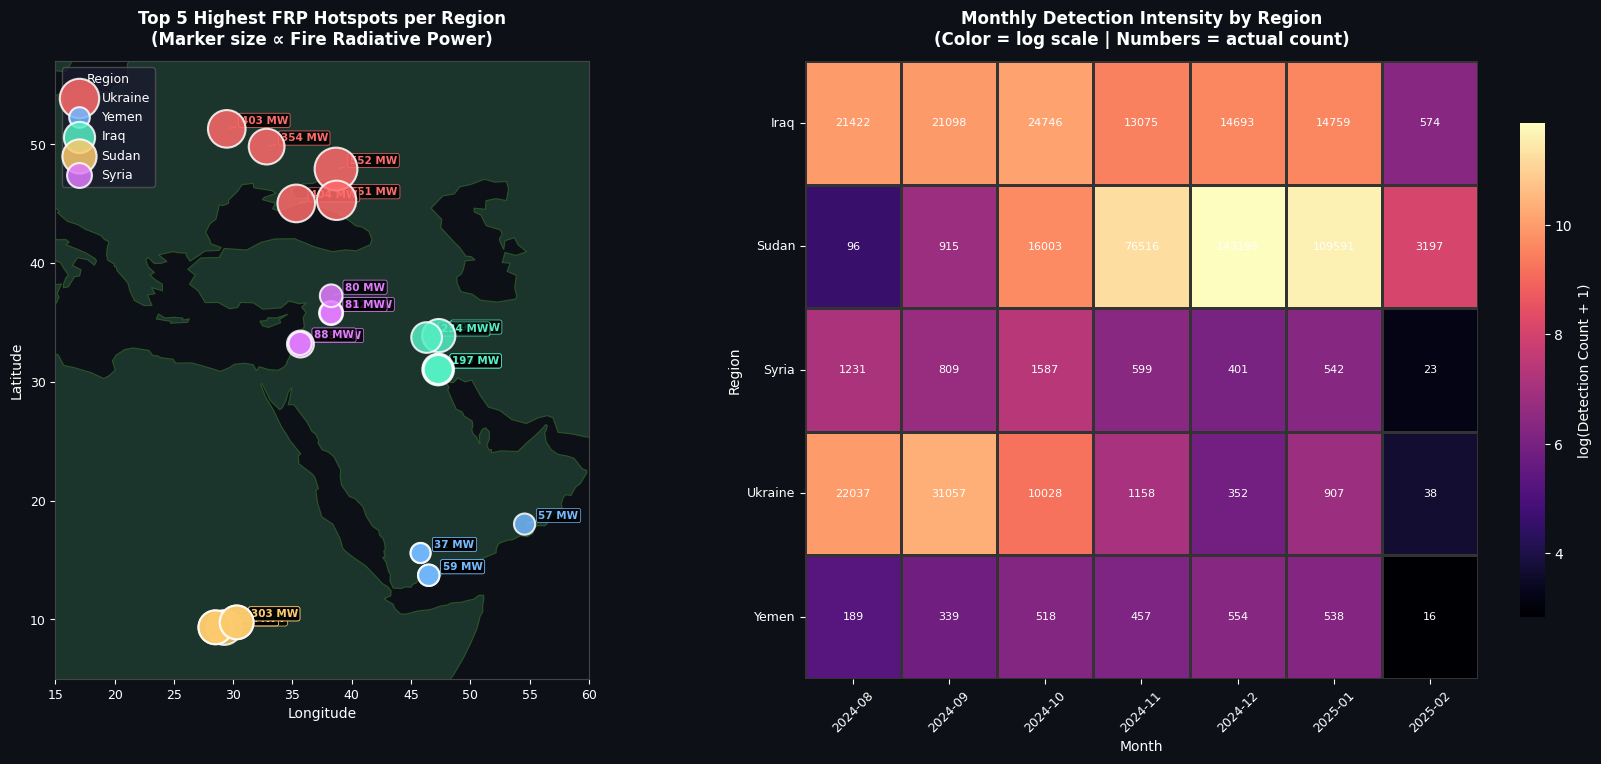

✓ Grafik kaydedildi


In [7]:
# Cell 8 (pro v3)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')
top_hotspots = []
for region in df_firms['region'].unique():
    subset = df_firms[df_firms['region'] == region].nlargest(5, 'frp').copy()
    subset['region'] = region
    top_hotspots.append(subset)
top_hotspots = pd.concat(top_hotspots, ignore_index=True)

df_firms['month'] = df_firms['acq_date'].dt.to_period('M')
pivot = df_firms.groupby(['region', 'month']).size().reset_index(name='count')
pivot['month'] = pivot['month'].astype(str)
pivot_table = pivot.pivot(index='region', columns='month', values='count').fillna(0)

# === Plot 1 ===
world.plot(ax=axes[0], color='#1e3a2f', edgecolor='#2d5a27', linewidth=0.8, alpha=0.9)
axes[0].set_facecolor('#0d1117')

region_styles = {
    'Ukraine': '#ff6b6b',
    'Yemen':   '#74b9ff',
    'Iraq':    '#55efc4',
    'Sudan':   '#fdcb6e',
    'Syria':   '#e17cff',
}

for region, color in region_styles.items():
    data = top_hotspots[top_hotspots['region'] == region]
    sizes = (data['frp'] / top_hotspots['frp'].max() * 800 + 150)
    axes[0].scatter(
        data['longitude'], data['latitude'],
        c=color, s=sizes, alpha=0.85,
        label=region, edgecolors='white', linewidth=1.5,
        zorder=5
    )
    for _, row in data.iterrows():
        axes[0].annotate(
            f"{row['frp']:.0f} MW",
            xy=(row['longitude'], row['latitude']),
            xytext=(10, 4), textcoords='offset points',
            fontsize=7.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2',
                     facecolor='#000000cc',
                     edgecolor=color,
                     linewidth=0.5),
            arrowprops=dict(arrowstyle='-',
                          color=color, lw=0.8, alpha=0.6)
        )

axes[0].set_xlim(15, 60)
axes[0].set_ylim(5, 57)
axes[0].set_title('Top 5 Highest FRP Hotspots per Region\n(Marker size ∝ Fire Radiative Power)',
                  fontsize=12, fontweight='bold', color='white', pad=12)
axes[0].set_xlabel('Longitude', color='white', fontsize=10)
axes[0].set_ylabel('Latitude', color='white', fontsize=10)
axes[0].tick_params(colors='white', labelsize=9)
for spine in axes[0].spines.values():
    spine.set_edgecolor('#444')
legend = axes[0].legend(loc='upper left', fontsize=9,
                        facecolor='#1a1a2e', edgecolor='#555',
                        labelcolor='white', title='Region',
                        title_fontsize=9)
legend.get_title().set_color('white')

# === Plot 2: Heatmap ===
pivot_log = np.log1p(pivot_table)
sns.heatmap(pivot_log, ax=axes[1], cmap='magma',
            linewidths=0.8, linecolor='#333',
            annot=pivot_table.astype(int), fmt='d',
            annot_kws={'size': 8, 'color': 'white'},
            cbar_kws={'label': 'log(Detection Count + 1)', 'shrink': 0.8})

axes[1].set_title('Monthly Detection Intensity by Region\n(Color = log scale | Numbers = actual count)',
                  fontsize=12, fontweight='bold', pad=12, color='white')
axes[1].set_xlabel('Month', fontsize=10, color='white')
axes[1].set_ylabel('Region', fontsize=10, color='white')
axes[1].tick_params(axis='x', rotation=45, labelsize=9, colors='white')
axes[1].tick_params(axis='y', rotation=0, labelsize=9, colors='white')
axes[1].set_facecolor('#0d1117')

cbar = axes[1].collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

plt.tight_layout(pad=2)
plt.savefig('../hotspot_heatmap.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Grafik kaydedildi")